XGBoost not installed, skipping XGBoost.
Columns: Index(['pH', 'Soil EC', 'Phosphorus', 'Potassium', 'Urea', 'T.S.P', 'M.O.P',
       'Moisture', 'Temperature', 'Plant Type'],
      dtype='object')
         pH   Soil EC  Phosphorus   Potassium       Urea      T.S.P  \
0  6.021428  0.237700   15.987947  133.206193  45.627373  16.952809   
1  6.342420  0.211844   15.305906  137.856536  59.460887  18.378723   
2  6.684784  0.290343   14.778959  132.994257  53.567383  17.207365   
3  6.552203  0.407055   12.328408  109.766048  41.053263  12.086209   
4  6.705262  0.533824   11.215420  102.429536  37.250965  14.953550   

       M.O.P   Moisture  Temperature Plant Type  
0  23.362074  79.234006    52.094083    Carrots  
1  22.143606  75.612889    51.349760    Carrots  
2  27.448977  77.277833    61.162072    Carrots  
3  21.630035  76.426754    72.280843    Carrots  
4  24.008938  76.718368    58.710557    Carrots  

Plant Type distribution:
 Plant Type
Carrots         10000
Chili          

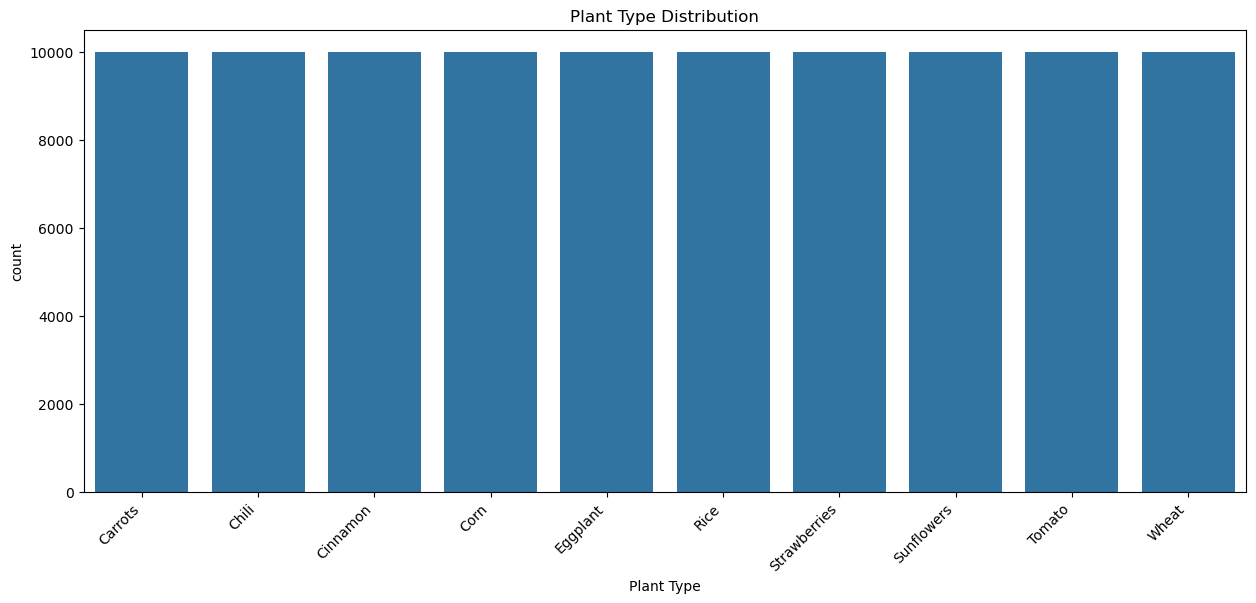


Model Accuracies:
Decision Tree: 0.8957
Random Forest: 0.9075

Best Model: Random Forest with Accuracy: 0.9075


C:\Users\HP\AppData\Local\Temp\ipykernel_14312\1629223845.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance, palette="viridis")


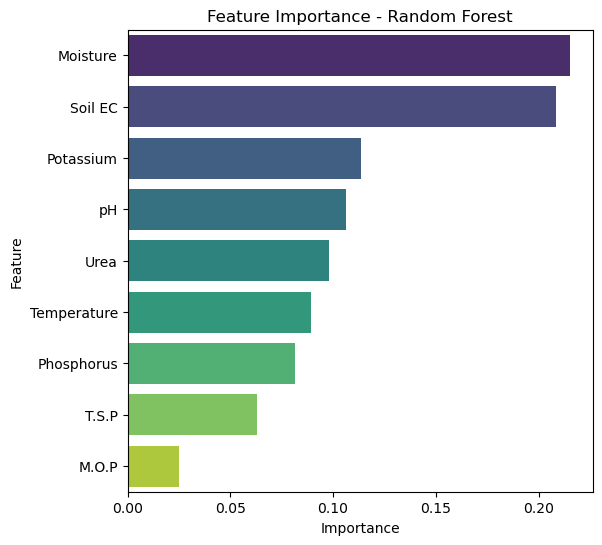

Recommended Plant: ['Cinnamon']


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Step 0: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Optional: XGBoost
try:
    from xgboost import XGBClassifier
    xgb_installed = True
except ModuleNotFoundError:
    print("XGBoost not installed, skipping XGBoost.")
    xgb_installed = False

# Step 1: Load dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\CV_PROJECTS\crop_csv.zip")

# Step 2: Quick EDA
print("Columns:", df.columns)
print(df.head())
print("\nPlant Type distribution:\n", df["Plant Type"].value_counts())

plt.figure(figsize=(15,6))
sns.countplot(x="Plant Type", data=df)
plt.xticks(rotation=45, ha='right')
plt.title("Plant Type Distribution")
plt.show()

# Step 3: Features & Target
X = df.drop("Plant Type", axis=1)
y = df["Plant Type"]

# Encode categorical features if any
X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col])

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Step 5: Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

if xgb_installed:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Step 6: Train models and store accuracy
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (acc, model)

# Step 7: Check best model
best_model_name = max(results, key=lambda x: results[x][0])
best_accuracy, best_model = results[best_model_name]

print("\nModel Accuracies:")
for name, (acc, _) in results.items():
    print(f"{name}: {acc:.4f}")
print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")

# Step 8: Feature Importance (if available)
if best_model_name in ["Random Forest", "XGBoost", "Decision Tree"]:
    importance = best_model.feature_importances_
    feat_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(6,6))
    sns.barplot(x='Importance', y='Feature', data=feat_importance, palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()

# Step 9: Predict new crop
sample = [[6.5, 0.5, 40, 50, 20, 10, 15, 60, 25]]  # Example input matching your features
prediction = best_model.predict(sample)
print("Recommended Plant:", prediction)